<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/ConceptAI/FruitinAmazon.zip'
data_path = '/content/drive/MyDrive/ConceptAI'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/ConceptAI/FruitinAmazon.zip' to '/content/drive/MyDrive'


In [ ]:
pip install keras tensorflow

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


#Simple CNN Implemented using Keras.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
  layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(64, (3, 3), activation="relu"),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(128, activation="relu"),
  layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 37ms/step - accuracy: 0.9603 - loss: 0.1258 - val_accuracy: 0.9851 - val_loss: 0.0438
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9870 - loss: 0.0419 - val_accuracy: 0.9878 - val_loss: 0.0371
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9907 - loss: 0.0292 - val_accuracy: 0.9887 - val_loss: 0.0343
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9934 - loss: 0.0200 - val_accuracy: 0.9902 - val_loss: 0.0309
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9953 - loss: 0.0143 - val_accuracy: 0.9895 - val_loss: 0.0376
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9895 - loss: 0.0376
Test accuracy: 0.9895
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


#Implement an End to End CNN Model for Image Classification Task.

Task 1: Data Understanding and Visualization:

Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

• What did you Observe?

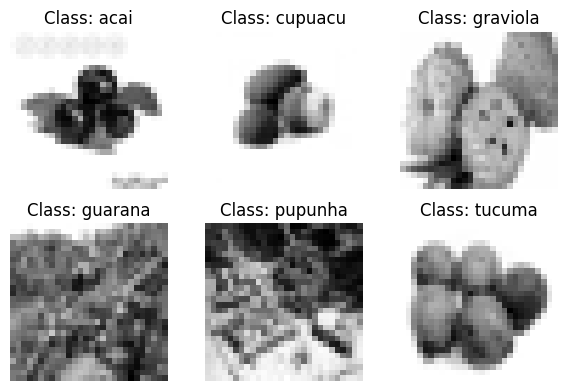

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Define dataset paths (from previous cells)
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
img_height, img_width = 28, 28

# Get the list of class directories from the train folder
class_names = sorted(os.listdir(train_dir))

# Prepare to store selected images and their labels
selected_images = []
selected_labels = []

# Select one image randomly from each class
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # Get all image filenames in the class directory
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            # Select a random image from the current class
            random_image_file = random.choice(image_files)
            img_path = os.path.join(class_path, random_image_file)

            # Load image using PIL, convert to grayscale, resize, and normalize
            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0 # Normalize pixel values to [0,1]

            selected_images.append(img)
            selected_labels.append(class_name)

# Display the images in a grid format with two rows using matplotlib
# Calculate grid dimensions: 2 rows and ceil(num_classes / 2) columns
num_classes = len(selected_images)
num_cols = (num_classes + 1) // 2 # Integer division to get number of columns for two rows

plt.figure(figsize=(num_cols * 2, 2 * 2)) # Adjust figure size dynamically
for i in range(num_classes):
    plt.subplot(2, num_cols, i + 1)
    plt.imshow(selected_images[i], cmap='gray')
    plt.title(f"Class: {selected_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Onservations:
The dataset is organized into multiple class folders, where each class represents a different fruit type such as acai, cupuacu, graviola, guarana, pupunha, and tucuma. One randomly selected image from each class shows that the images vary in appearance, including differences in shape, texture, and arrangement of the fruits. The images appear to be grayscale and somewhat low in resolution, which may make feature extraction slightly more challenging. However, each class still shows distinct visual patterns, indicating that the dataset is suitable for training a CNN model for classification.

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”  

• Hint:

– Iterate through each class subdirectory and check if each image is valid.

– Use the Image.open() function to attempt to load each image.

– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".

– Maintain a list of all corrupted image paths for reporting.

• Expected Output: No corrupted images found.

In [ ]:
import os
from PIL import Image

# Define dataset paths (from previous cells)
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"

# List to store corrupted image paths
corrupted_images = []

# Loop through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            image_path = os.path.join(class_path, file_name)

            # Check only files
            if os.path.isfile(image_path):
                try:
                    with Image.open(image_path) as img:
                        img.verify()   # verifies if image is valid
                except (IOError, SyntaxError, OSError):
                    corrupted_images.append(image_path)
                    os.remove(image_path)
                    print(f"Removed corrupted image: {image_path}")

# Final report
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print("\nTotal corrupted images removed:", len(corrupted_images))

No Corrupted Images Found.


#Task 2:
Loading and Preprocessing Image Data in keras:

In this section, we will load and preprocess image data from a directory using the
image dataset from directory function in Keras.

This function is used to load images from a directory structure where subdirectories represent different
classes. We will also apply basic preprocessing, including resizing and batching and normalization of
images. The same function can be used to load train and validation data.

Found 90 files belonging to 6 classes.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


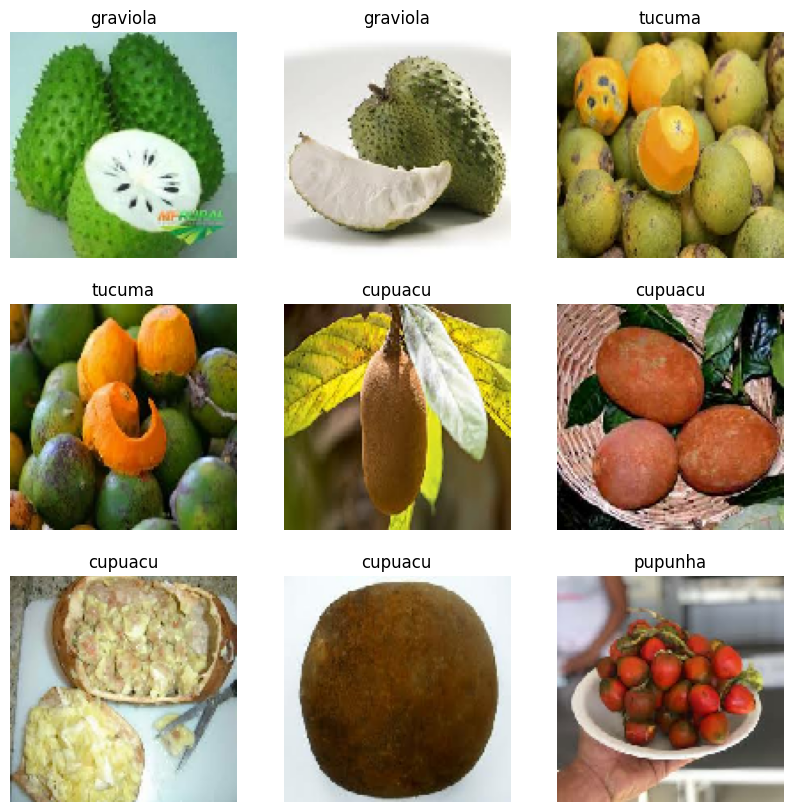

In [ ]:
import tensorflow as tf

# Define parameters for image loading and preprocessing
img_height = 128  # You can adjust this as needed
img_width = 128   # You can adjust this as needed
batch_size = 16 # Changed batch_size to 16 as requested

# Define dataset paths (from previous cells)
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
val_dir = "/content/drive/MyDrive/FruitinAmazon/test"

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

# Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=42
)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Display a batch of images and labels from the training set to verify
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

#Task 3 - Implement a CNN with

Follow the following Structure and Hyper - parameters:

Convolutional Architecture:

• Convolutional Layer 1:

– Filter Size (F): (3, 3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 1: Max pooling

– Filter Size (F): (2, 2)

– Stride (s): 2

• Convolutional Layer 2:

– Filter Size (F): (3, 3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 2: Max pooling

– Filter Size (F): (2, 2)

– Stride (s): 2

Fully Connected Network Architecture:

• Flatten Layer: Flatten the input coming from the convolutional layers

• Input Layer:

• Hidden Layer - 2:

– Number of Neurons: 64

– Number of Neurons: 128

• Output Layer:

– Number of Neurons: num classes (number of output classes)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Get img_height, img_width, and num_classes from previous steps
# (Assuming these variables are already defined in the notebook's scope)

model = keras.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Network
    layers.Dense(128, activation='relu'), # Hidden Layer 1
    layers.Dense(64, activation='relu'),  # Hidden Layer 2

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Compile the Model
Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
checkpoint_filepath = 'best_model.keras' # Save best model based on validation accuracy
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=20, # Stop if validation accuracy doesn't improve for 20 epochs
    mode='max',
    restore_best_weights=True,
    verbose=1
)

callbacks = [model_checkpoint_callback, early_stopping_callback]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250, # Set to 250 epochs as requested
    callbacks=callbacks
)

Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9221 - loss: 0.8186
Epoch 1: val_accuracy improved from None to 0.63333, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 657ms/step - accuracy: 0.8667 - loss: 1.1417 - val_accuracy: 0.6333 - val_loss: 3.8890
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.9680 - loss: 0.1148
Epoch 2: val_accuracy did not improve from 0.63333
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 354ms/step - accuracy: 0.9556 - loss: 0.1650 - val_accuracy: 0.3000 - val_loss: 2.9858
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9930 - loss: 0.1088
Epoch 3: val_accuracy did not improve from 0.63333
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.9889 - loss: 0.1669 - val_accuracy: 0.3333 - val_loss: 2.8032
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 1.0000 - loss: 0.0345
Epoch 4: val_accuracy did not improve from 0.63333
6/6 ━━━━━━━━━━━━━━━━━━━━

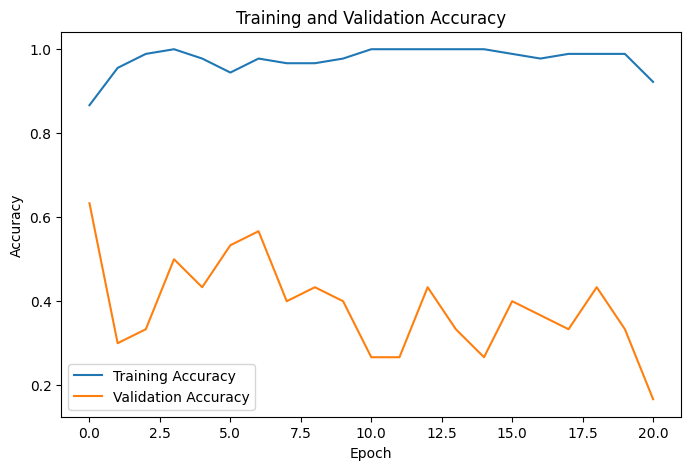

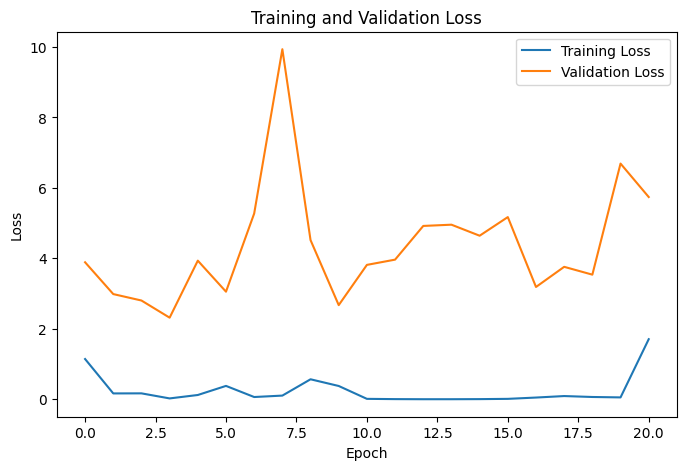

In [ ]:
# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

#Task 5: Evaluate the Model
Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [ ]:
import tensorflow as tf

# Evaluate the model on the validation dataset (which serves as the test set)
loss, accuracy = model.evaluate(val_ds)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6333 - loss: 3.8890
Test Loss: 3.8890
Test Accuracy: 0.6333


#Task 6: Save and Load the Model
Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [ ]:
import tensorflow as tf

# Define the filename for saving the model
model_save_path = 'my_image_classifier_model.h5'

# Save the trained model to an .h5 file
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

# Load the saved model
loaded_model = tf.keras.models.load_model(model_save_path)
print(f"Model loaded from {model_save_path}")

# Re-evaluate the loaded model's performance on the test set
loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)

print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_accuracy:.4f}")

Model saved to my_image_classifier_model.h5
Model loaded from my_image_classifier_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6333 - loss: 3.8890
Loaded Model Test Loss: 3.8890
Loaded Model Test Accuracy: 0.6333


#Task 7: Predictions and Classification Report
Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels from the validation dataset
true_labels = []
for images, labels in val_ds:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)

# Make predictions on the validation dataset
# Since val_ds is batched, model.predict will handle it directly
predictions_proba = model.predict(val_ds)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions_proba, axis=1)

# Get class names for the report
# class_names was defined when loading train_ds and val_ds

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step

Classification Report:
              precision    recall  f1-score   support

        acai       1.00      0.80      0.89         5
     cupuacu       0.50      0.20      0.29         5
    graviola       0.45      1.00      0.62         5
     guarana       0.83      1.00      0.91         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.57      0.80      0.67         5

    accuracy                           0.63        30
   macro avg       0.56      0.63      0.56        30
weighted avg       0.56      0.63      0.56        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
